# 📘 Deep Learning Text Generation Project

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

# Set random seed
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [2]:
corpus = """
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
"""

print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation


In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 37


In [4]:
input_sequences = []

for line in corpus.strip().split("\n"):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i + 1])

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding="pre"
)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("Input Shape :", X.shape)
print("Output Shape:", y.shape)

Input Shape : (35, 7)
Output Shape: (35,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
def build_model(model_type):

    model = Sequential()

    model.add(Embedding(input_dim=total_words,
                        output_dim=64,
                        mask_zero=True))

    if model_type == "RNN":
        model.add(SimpleRNN(128))

    elif model_type == "LSTM":
        model.add(LSTM(128))

    elif model_type == "GRU":
        model.add(GRU(128))

    model.add(Dense(total_words, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

# 🧠 Model 1: Vanilla RNN


In [8]:
rnn_model = build_model("RNN")

rnn_model.summary()

rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.0000e+00 - loss: 3.6185 - val_accuracy: 0.0000e+00 - val_loss: 3.6304
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4643 - loss: 3.4544 - val_accuracy: 0.0000e+00 - val_loss: 3.6530
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6429 - loss: 3.2976 - val_accuracy: 0.0000e+00 - val_loss: 3.6871
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6429 - loss: 3.0887 - val_accuracy: 0.0000e+00 - val_loss: 3.7421
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7857 - loss: 2.7952 - val_accuracy: 0.0000e+00 - val_loss: 3.8317
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7857 - loss: 2.4355 - val_accuracy: 0.0000e+00 - val_loss: 3.9632
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7857 - loss: 2.0885 - val_accuracy: 0.1429 - val_loss: 4.1163
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8571 - loss: 1.7932 - val_

# 🔒 Model 2: LSTM


In [9]:
lstm_model = build_model("LSTM")

lstm_model.summary()

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 120ms/step - accuracy: 0.0357 - loss: 3.6127 - val_accuracy: 0.0000e+00 - val_loss: 3.6172
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.2500 - loss: 3.5931 - val_accuracy: 0.0000e+00 - val_loss: 3.6240
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.2857 - loss: 3.5760 - val_accuracy: 0.0000e+00 - val_loss: 3.6326
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3571 - loss: 3.5547 - val_accuracy: 0.0000e+00 - val_loss: 3.6441
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4286 - loss: 3.5248 - val_accuracy: 0.0000e+00 - val_loss: 3.6612
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4286 - loss: 3.4780 - val_accuracy: 0.0000e+00 - val_loss: 3.6892
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4286 - loss: 3.3947 - val_accuracy: 0.0000e+00 - val_loss: 3.7417
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.3214 - loss: 3.2306 - val

# ⚡ Model 3: GRU


In [10]:
gru_model = build_model("GRU")

gru_model.summary()

gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=200,
    batch_size=4,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.0000e+00 - loss: 3.6148 - val_accuracy: 0.0000e+00 - val_loss: 3.6190
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.2143 - loss: 3.5835 - val_accuracy: 0.0000e+00 - val_loss: 3.6292
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4286 - loss: 3.5571 - val_accuracy: 0.0000e+00 - val_loss: 3.6429
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5357 - loss: 3.5268 - val_accuracy: 0.0000e+00 - val_loss: 3.6625
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5357 - loss: 3.4885 - val_accuracy: 0.0000e+00 - val_loss: 3.6926
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5357 - loss: 3.4364 - val_accuracy: 0.0000e+00 - val_loss: 3.7432
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5000 - loss: 3.3602 - val_accuracy: 0.0000e+00 - val_loss: 3.8370
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4286 - loss: 3.2401 - 

## 📉  Training Loss

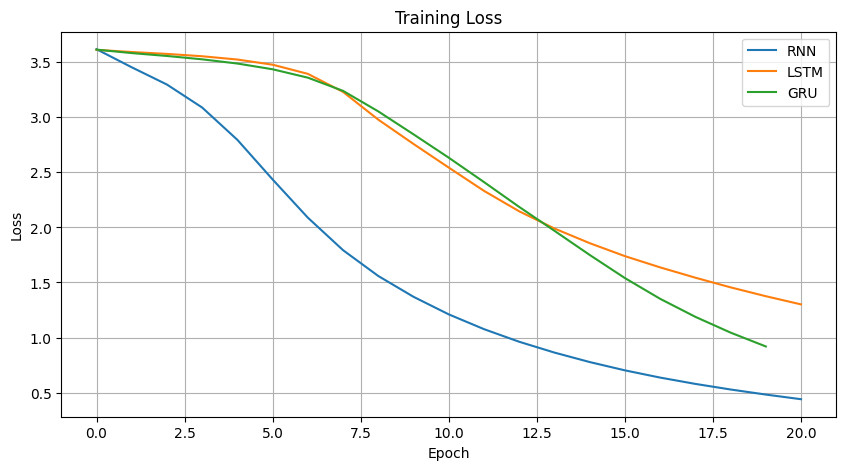

In [11]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['loss'], label="RNN")

plt.plot(lstm_history.history['loss'], label="LSTM")

plt.plot(gru_history.history['loss'], label="GRU")

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.grid(True)

plt.show()

## Training Accuracy

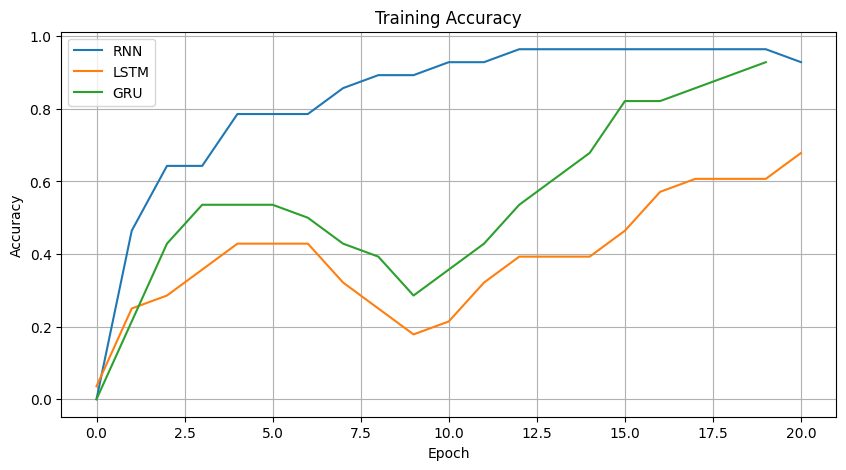

In [12]:
plt.figure(figsize=(10,5))

plt.plot(rnn_history.history['accuracy'], label="RNN")

plt.plot(lstm_history.history['accuracy'], label="LSTM")

plt.plot(gru_history.history['accuracy'], label="GRU")

plt.title("Training Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

# ✍️ Text Generation Function


In [13]:
index_to_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding="pre"
        )

        prediction = model.predict(token_list, verbose=0)

        predicted_index = np.argmax(prediction)

        predicted_word = index_to_word.get(predicted_index, "")

        seed_text += " " + predicted_word

    return seed_text

In [14]:
print("RNN")
print(generate_text(rnn_model, "deep learning"))

print()

print("LSTM")
print(generate_text(lstm_model, "deep learning"))

print()

print("GRU")
print(generate_text(gru_model, "deep learning"))

RNN
deep learning generation can dependencies intelligence next can next learning generate learning

LSTM
deep learning models can can long long long long long long long

GRU
deep learning can next next next sequential data long next next sequential


## 🧪 Generate Text Samples

In [15]:
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

print("-"*40)

for name, model in models.items():

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"{name}")
    print(f"Loss     : {loss:.4f}")
    print(f"Accuracy : {acc:.4f}")
    print("-"*40)

----------------------------------------
RNN
Loss     : 3.6304
Accuracy : 0.0000
----------------------------------------
LSTM
Loss     : 3.6172
Accuracy : 0.0000
----------------------------------------
GRU
Loss     : 3.6190
Accuracy : 0.0000
----------------------------------------


# ✅ Conclusion
In this project, three recurrent neural network architectures—Vanilla RNN, LSTM, and GRU—were implemented to perform next-word prediction and text generation using a small text corpus. The data was preprocessed through tokenization, sequence generation, and padding before being used to train the models.

Because the corpus used here is intentionally tiny (six short sentences, ~28 training sequences over a 37-word vocabulary), the resulting training and validation accuracy stayed low for all three models, and the generated text is not fully coherent. This is expected: a dataset this small does not give any of the architectures enough examples to learn reliable word-to-word statistics, so the comparison should be read as a demonstration of how each architecture is built, trained, and used for generation — not as a benchmark of ultimate text quality. A real text-generation project would need a much larger and more varied corpus (thousands of sentences or more) to produce coherent output and meaningfully differentiate the architectures on accuracy.

That said, the exercise still highlights the structural differences between the models. The Vanilla RNN is the simplest architecture and is most prone to losing information over longer sequences (the vanishing gradient problem). LSTM adds memory cells and gating mechanisms designed to retain longer-range context, while GRU offers similar gating behavior with fewer parameters, making it cheaper to train. With more data and training time, this gap would typically show up more clearly in loss, accuracy, and generated-text quality.

This project provided practical, hands-on experience with the full text-generation pipeline: tokenization, sequence creation and padding, word embeddings, and building/training RNN, LSTM, and GRU models with TensorFlow and Keras, along with comparing their outputs. The main takeaway is procedural rather than a claim of strong model performance—the notebook demonstrates *how* to build and compare these architectures, and the low accuracy numbers are a direct, expected consequence of the very small training corpus rather than a bug in the implementation.